# Reusing FAIR potato GxE phenotyping data - SPARQL + PBTT demonstration

Reproduction target: **Papoutsoglou, E.A., Athanasiadis, I.N., Visser, R.G.F. & Finkers, R. "The benefits and struggles of FAIR data: the case of reusing plant phenotyping data.", *Scientific Data* 10:457 (2023).** [DOI: 10.1038/s41597-023-02364-z](https://doi.org/10.1038/s41597-023-02364-z) - open access, CC BY 4.0.

Author code: [PBR/FAIR_CxE](https://github.com/PBR/FAIR_CxE) tag `v1.0` (commit `485c6eb642f916f695b0602f69fa23ebfcffa0ae`, GPL-3.0), notebook `all_containers/common_files/Explore_data.ipynb`.

**Scope (partial demonstration, executed example):** this notebook re-runs the paper's data-*reuse* scenario on the authors' FAIRified RDF (five potato genotype-by-environment experiments: 1999NL, 2003VE, 2004Fin, 2005Fin, 2010ET):

1. SPARQL exploration of MIAPPE/PPEO study metadata;
2. verification that the experiments share genotypes (paper: **101 common genotypes**, 292 in total);
3. matching weather stations to experimental sites (AEMET ontology, squared-coordinate distance);
4. average tuber weight per genotype per experiment;
5. cumulative **photo-beta thermal time (PBTT)** per experiment and a best/worst environment plot per genotype.

**Adaptation (important):** the authors served their RDF with Apache Jena Fuseki (Docker) and queried it with `SPARQLWrapper`; `SERVICE` clauses federated a second Fuseki dataset. Google Colab cannot host that stack, so this notebook loads the **same pinned `data-generated/*.ttl` files into one in-memory `rdflib` graph** and runs the authors' **SPARQL query strings verbatim**, with the Fuseki `SERVICE` routing flattened (a no-op over a single store, because the phenotypic and weather triples use disjoint vocabularies). The BTT/PBTT helper functions are copied verbatim from the author notebook. Plots use matplotlib instead of Plotly so figures persist in saved outputs. The TTL files are parsed with an explicit shared base IRI so that the relative IRIs merge into one data model, exactly as under Fuseki. This is an AI-authored infrastructure adaptation, not author-provided code; the original Fuseki/FDP pipeline is not executed here.

(Japanese) 本ノートブックは論文のデータ再利用シナリオ(メタデータ探索、遺伝型の重複確認、気象ステーションの対応付け、塊茎重の集計、PBTT統合)を最小例で再実行します。著者のFuseki/SPARQLエンドポイントはColab用にメモリ内rdflibグラフへ置き換えましたが、SPARQLクエリ文字列とPBTT計算関数は著者コード(tag v1.0)から原文のまま再利用しています。著者提供のColab実装ではなく、Fusekiパイプライン自体は再実行していない点にご注意ください。

**Validation status:** executed top-to-bottom on a fresh Google Colab **CPU** runtime (see the final cell for the validation record and observed values).

In [ ]:
import importlib, sys
for pkg in ["rdflib", "pandas", "numpy", "matplotlib"]:
    if importlib.util.find_spec(pkg) is None:
        %pip install -q {pkg}
import rdflib, pandas as pd, numpy as np
import matplotlib
import matplotlib.pyplot as plt
print("python", sys.version.split()[0])
print("rdflib", rdflib.__version__, "| pandas", pd.__version__,
      "| numpy", np.__version__, "| matplotlib", matplotlib.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 10.9 MB/s eta 0:00:00


python 3.13.15
rdflib 7.6.0 | pandas 2.2.3 | numpy 2.1.3 | matplotlib 3.10.0


## Runtime selection / 実行環境

**Select "Runtime - Change runtime type - CPU" (recommended).** This notebook is pure RDF/SPARQL + pandas work - no GPU and no deep-learning framework is used; a GPU runtime adds nothing.

- Expected wall time on a free Colab CPU VM: ~5-15 minutes total (the largest single step is parsing ~25 MB of Turtle into rdflib).
- Downloads: 12 TTL files, ~25.3 MB total, from `raw.githubusercontent.com` at tag `v1.0` (integrity-checked in the next cell).
- Run all cells top to bottom ("Runtime - Run all"). No runtime restart is needed.

(Japanese) GPUは不要です。CPUランタイムを選択し「ランタイム - すべてのセルを実行」してください。全体で約5〜15分、ダウンロードは約25 MBです。

In [ ]:
import hashlib, urllib.request, os

BASE = "https://raw.githubusercontent.com/PBR/FAIR_CxE/v1.0/all_containers/common_files/"
# relative path -> (git blob sha1, expected byte size), from the GitHub tree of pinned
# commit 485c6eb642f916f695b0602f69fa23ebfcffa0ae (tag v1.0), recorded 2026-10-01
BLOBS = {"miappe_metadata.ttl": ["a613ec965975bb3b2065b060c3556723f6438369", 12619223], "phenotypic/data_1999NL.ttl": ["ace27e1522c434aaf37668fca22bad78429b95f9", 356811], "phenotypic/data_2003VE.ttl": ["7fd34f61fd1ba7ad1760d69950f2177e7dba65ed", 85558], "phenotypic/data_2004Fin.ttl": ["650c85189a54060954e9060c5a440642580fa658", 7518851], "phenotypic/data_2005Fin.ttl": ["824c2dfe44f44361dcf3e3d8e2f4a5a49e0c16d1", 3648782], "phenotypic/data_2010ET.ttl": ["51b9155bb721373b7fbf0211eaf8a6d2c41a17ca", 4665405], "station_metadata.ttl": ["a8f8cc448f7b1fff1a53baea9f03996aa45551bd", 1491], "weather/1999NL_weather.ttl": ["ddab3a16f9a98b991b727f6d900efa72246c4e3a", 113036], "weather/2003VE_weather.ttl": ["54b3a4d72879c8e2aa8379f2772434de53cb804a", 52785], "weather/2004Fin_weather.ttl": ["1d0149efa1e7ff6bfa3a134cdde8bc95ae1e6deb", 85119], "weather/2005Fin_weather.ttl": ["f91f1b2f3e0cd6de6f325f908b22146086c39446", 73601], "weather/2010ET_weather.ttl": ["43e6e21a292bb78b05f9433ccb7e03da323a8366", 79131]}

def git_blob_sha1(data: bytes) -> str:
    return hashlib.sha1(b"blob %d\x00" % len(data) + data).hexdigest()

os.makedirs("data-generated", exist_ok=True)
rows = []
for rel, (want_sha, want_size) in BLOBS.items():
    dest = os.path.join("data-generated", rel)
    os.makedirs(os.path.dirname(dest), exist_ok=True)
    urllib.request.urlretrieve(BASE + "data-generated/" + rel, dest)
    with open(dest, "rb") as fh:
        data = fh.read()
    got_sha = git_blob_sha1(data)
    ok = (got_sha == want_sha) and (len(data) == want_size)
    rows.append((rel, len(data), got_sha[:12], "OK" if ok else "MISMATCH"))
    assert ok, "integrity check failed for " + rel

pd.DataFrame(rows, columns=["file", "bytes", "git blob sha1 (first 12)", "check"])

,file,bytes,git blob sha1 (first 12),check
0,miappe_metadata.ttl,12619223,a613ec965975,OK
1,phenotypic/data_1999NL.ttl,356811,ace27e1522c4,OK
2,phenotypic/data_2003VE.ttl,85558,7fd34f61fd1b,OK
3,phenotypic/data_2004Fin.ttl,7518851,650c85189a54,OK
4,phenotypic/data_2005Fin.ttl,3648782,824c2dfe44f4,OK
5,phenotypic/data_2010ET.ttl,4665405,51b9155bb721,OK
6,station_metadata.ttl,1491,a8f8cc448f7b,OK
7,weather/1999NL_weather.ttl,113036,ddab3a16f9a9,OK
8,weather/2003VE_weather.ttl,52785,54b3a4d72879,OK
9,weather/2004Fin_weather.ttl,85119,1d0149efa1e7,OK


## 0. Environment setup

`rdflib` (SPARQL 1.1 engine), `pandas`, `numpy` and `matplotlib` are used. Colab ships these preinstalled; we check versions and install only what is missing.

(Japanese) 必要ライブラリの確認と、欠けている場合のみインストールします。

In [ ]:
import time, glob

g = rdflib.Graph()
t0 = time.time()
for path in sorted(glob.glob("data-generated/**/*.ttl", recursive=True)):
    tp = time.time()
    g.parse(path, format="turtle", publicID="https://example.org/cxe/")
    print(f"parsed {path:<45} ({time.time()-tp:5.1f} s)")
print(f"TOTAL: {len(g)} triples in {time.time()-t0:.1f} s")

Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/rdflib/term.py", line 2262, in _castLexicalToPython
    return conv_func(lexical)  # type: ignore[arg-type]
  File "/usr/local/lib/python3.13/dist-packages/rdflib/xsd_datetime.py", line 587, in parse_xsd_date
    return parse_date(date_string if not minus else ("-" + date_string))
ValueError: Invalid isoformat string: ' 1999-11-14'


parsed data-generated/miappe_metadata.ttl            (  9.6 s)


parsed data-generated/phenotypic/data_1999NL.ttl     (  0.3 s)
parsed data-generated/phenotypic/data_2003VE.ttl     (  0.1 s)


parsed data-generated/phenotypic/data_2004Fin.ttl    (  7.5 s)


parsed data-generated/phenotypic/data_2005Fin.ttl    (  5.0 s)


...

parsed data-generated/phenotypic/data_2010ET.ttl     (  4.2 s)
parsed data-generated/station_metadata.ttl           (  0.0 s)
parsed data-generated/weather/1999NL_weather.ttl     (  0.2 s)


Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/rdflib/term.py", line 2262, in _castLexicalToPython
    return conv_func(lexical)  # type: ignore[arg-type]
ValueError: could not convert string to float: ''


Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/rdflib/term.py", line 2262, in _castLexicalToPython
    return conv_func(lexical)  # type: ignore[arg-type]
ValueError: could not convert string to float: ''


parsed data-generated/weather/2003VE_weather.ttl     (  0.1 s)
parsed data-generated/weather/2004Fin_weather.ttl    (  0.1 s)


parsed data-generated/weather/2005Fin_weather.ttl    (  0.1 s)
parsed data-generated/weather/2010ET_weather.ttl     (  0.1 s)
TOTAL: 432732 triples in 27.2 s


## 1. Acquire the authors' FAIRified data (RDF/Turtle)

We download the 12 `data-generated` TTL files (MIAPPE metadata, phenotypic observations per experiment, weather-station metadata, per-experiment weather observations) from the pinned repository tag `v1.0`, then verify each file's **Git blob SHA-1** (`sha1("blob <size>\0" + bytes)`) against the blob IDs recorded in the GitHub tree of pinned commit `485c6eb642f916f695b0602f69fa23ebfcffa0ae`. A mismatch aborts the notebook.

(Japanese) 著者リポジトリ tag v1.0 からTTL形式のRDFデータ12ファイル(約25 MB)をダウンロードし、Gitのblob SHA-1で完全性を確認します。

In [ ]:
def run_query(graph, sparql_query):
    # Run a SPARQL SELECT on the local rdflib graph and return a DataFrame
    # (adaptation of the author's query_DB + json_normalize plumbing).
    res = graph.query(sparql_query)
    cols = [str(v) for v in res.vars]
    rows = [[str(r[c]) if r[c] is not None else None for c in cols] for r in res]
    return pd.DataFrame(rows, columns=cols)

# ---- verbatim from PBR/FAIR_CxE v1.0, Explore_data.ipynb cell 0 ----
def formula_btt(t):
    # fixed values based on potato
    tb = 5.5
    to = 23.4
    tc = 34.6
    ct = 1.7 
    btt = (
            ((tc - t) / (tc - to)) * 
            ((t - tb) / (to - tb)) ** 
            ((to - tb) / (tc - to))
           ) ** ct
    try:
        return btt if btt > 0 else 0
    except:
        return 0


def calculate_PBTT(df_w_cur):    
    df_w_cur = df_w_cur.dropna()
    df_w_cur['mean_temperature'] = pd.to_numeric(df_w_cur['mean_temperature'])
    df_w_cur['hours_of_sunlight'] = pd.to_numeric(df_w_cur['hours_of_sunlight'])
    #df_w_cur = df_w_cur.where(pd.notnull(df_w_cur), None)

    df_w_cur['BTT'] = df_w_cur.apply(
        lambda row: formula_btt(row.mean_temperature), 
        axis = 1) 
    df_w_cur['day_fraction'] = df_w_cur.apply(
        lambda row: row.hours_of_sunlight / 24.0,
        axis = 1)
    df_w_cur['PBTT'] = df_w_cur.apply(
        lambda row: (row.BTT * row.day_fraction) if row.BTT > 0 else 0,
        axis = 1) 
    df_w_cur['cum_PBTT'] = df_w_cur['PBTT'].cumsum()
    cum_pbtt = df_w_cur.loc[df_w_cur.index[-1], 'cum_PBTT']
    return df_w_cur, cum_pbtt



## 2. Load the RDF into one in-memory graph

The authors loaded the same TTL files into Fuseki (two datasets: `pheno` and `weather`) and federated them with SPARQL `SERVICE`. Here we load all files into **one** `rdflib.Graph`; the phenotypic (MIAPPE/PPEO) and weather (AEMET) triples use disjoint vocabularies, so a single store is equivalent, and `SERVICE` becomes a no-op.

**Important detail:** the TTL files use *relative* IRIs (e.g. `#variable/...`, `#data_file/...`), which are resolved against each file's own location by default. When Jena Fuseki loads these files into one store the relative identifiers merge into shared nodes; plain rdflib parsing would keep them separate and the author's joins would return nothing. We therefore pass an explicit shared base (`publicID="https://example.org/cxe/"`) to every `parse()` call — a verified compatibility adaptation that reproduces the author's data model (checked: the author's genotype-overlap and tuber-weight queries then return the paper's counts).

Parsing ~25 MB of Turtle takes a few minutes on CPU; the cell prints elapsed time and the total triple count.

(Japanese) 12個のTTLを1つのメモリ内グラフに読み込みます(Fusekiの2データセット+SERVICE連携の等価な置換)。数分かかることがあります。

In [ ]:
QUERY_STUDIES = '''    PREFIX ppeo: <http://purl.org/ppeo/PPEO.owl#> 

    SELECT distinct ?studyId ?cntName ?addr ?locName ?startDate ?endDate ?lat ?long ?alt 
    WHERE {
        ?study a ppeo:study ;
               ppeo:hasIdentifier ?studyId ;
               ppeo:hasStartDateTime ?startDate ;
               ppeo:hasEndDateTime ?endDate ;
               ppeo:hasLocation ?studyloc .

        ?studyloc ppeo:hasCountry ?cnt ;
                  ppeo:hasLatitude ?lat ;
                  ppeo:hasLongitude ?long ;
                  ppeo:hasAltitude ?alt ;
                  ppeo:hasAddress ?addr ;
                  ppeo:hasName ?locName .
        ?cnt ppeo:hasName ?cntName .
    }
    ORDER BY ?studyId
'''

df_studies = run_query(g, QUERY_STUDIES)
df_studies

,studyId,cntName,addr,locName,startDate,endDate,lat,long,alt
0,1999NL,NL,WUR field,Wageningen,1999-03-12,1999-11-14,52.0,5.63,11m
1,2003VE,VE,Mucupiche field in La Fresa,Merida,2003-06-24,2003-11-30,8.6,-71.13,2200m
2,2004Fin,FI,Field in North Ostrobothnia Research Station,Ruukki,2004-04-16,2004-11-10,64.7,25.0,48m
3,2005Fin,FI,Field in North Ostrobothnia Research Station,Ruukki,2005-05-03,2005-11-14,64.7,25.0,48m
4,2010ET,ET,Field in Holeta Agricultural Research Institute,Holeta,2010-07-16,2010-12-06,9.12,38.13,2400m


## 3. Query helper (adaptation of the author's `query_DB`) + verbatim PBTT functions

The author notebook sends each query to `http://fuseki:3030/pheno/query` via `SPARQLWrapper` and reshapes the JSON bindings with the long-removed `pandas.io.json.json_normalize`. Only this plumbing is adapted: `run_query()` executes the same SPARQL string on the local `rdflib` graph and returns a plain `DataFrame` with one column per SPARQL variable - behavior-equivalent for these SELECT queries.

The BTT/PBTT functions below are copied **verbatim** from author cell 0 of `Explore_data.ipynb` (tag `v1.0`), including the fixed potato cardinal temperatures `tb = 5.5 C, to = 23.4 C, tc = 34.6 C, ct = 1.7`.

(Japanese) 著者のquery_DB(SPARQLWrapper→Fuseki)を、同じクエリ文字列をローカルrdflibで実行するrun_queryに置き換えただけの等価な下請け関数です。PBTT計算関数は著者コードの原文コピー(基準温度 tb=5.5/to=23.4/tc=34.6 ℃、ct=1.7)。

In [ ]:
QUERY_OVERLAP  = '''    PREFIX ppeo: <http://purl.org/ppeo/PPEO.owl#> 

    SELECT distinct ?bio_mat_id
    WHERE {
        ?study1 a ppeo:study ;
            ppeo:hasBiologicalMaterial ?bio_mat ;
            ppeo:hasIdentifier '1999NL' .

        ?study2 a ppeo:study ;
            ppeo:hasBiologicalMaterial ?bio_mat ;
            ppeo:hasIdentifier '2005Fin' .

       ?study3 a ppeo:study ;
            ppeo:hasBiologicalMaterial ?bio_mat ;
            ppeo:hasIdentifier '2003VE' .

       ?study4 a ppeo:study ;
            ppeo:hasBiologicalMaterial ?bio_mat ;
            ppeo:hasIdentifier '2004Fin' .

       ?study5 a ppeo:study ;
            ppeo:hasBiologicalMaterial ?bio_mat ;
            ppeo:hasIdentifier '2010ET'  .

        ?bio_mat ppeo:hasIdentifier ?bio_mat_id .

    } 
    ORDER BY ?bio_mat_id
'''
QUERY_UNION    = '''    PREFIX ppeo: <http://purl.org/ppeo/PPEO.owl#> 

    SELECT distinct ?bio_mat_id
    WHERE {
        ?study1 a ppeo:study ;
            ppeo:hasBiologicalMaterial ?bio_mat .
        ?bio_mat ppeo:hasIdentifier ?bio_mat_id .

    } 
    ORDER BY ?bio_mat_id
'''
QUERY_PER_EXPT = '''    PREFIX ppeo: <http://purl.org/ppeo/PPEO.owl#> 

    SELECT (?study_id as ?Study_ID) (count(distinct ?bio_mat_id) as ?genotypes)
    WHERE {
        ?study a ppeo:study ;
            ppeo:hasBiologicalMaterial ?bio_mat ;
            ppeo:hasIdentifier ?study_id .
        ?bio_mat ppeo:hasIdentifier ?bio_mat_id .
    } GROUP BY ?study_id

'''

df_common = run_query(g, QUERY_OVERLAP)
df_all    = run_query(g, QUERY_UNION)
df_per    = run_query(g, QUERY_PER_EXPT)
print(f"common to all five experiments: {len(df_common)} (paper: 101)")
print(f"total distinct genotypes:       {len(df_all)} (paper: 292)")
df_per.sort_values("Study_ID")

common to all five experiments: 101 (paper: 101)
total distinct genotypes:       292 (paper: 292)


,Study_ID,genotypes
1,1999NL,242
0,2003VE,107
4,2004Fin,251
3,2005Fin,260
2,2010ET,190


## 4. Explore the study metadata (milestone: explore the metadata)

Author query (section 1.3 of `Explore_data.ipynb`): one row per study with country, location name/address, GPS coordinates, altitude and the experimental time window.

(Japanese) MIAPPEメタデータから5試験の国・場所・期間・GPS・標高を取得します。

In [ ]:
QUERY_STATIONS = '''    PREFIX aemet: <http://aemet.linkeddata.es/ontology/> 
    PREFIX geo: <http://www.w3.org/2003/01/geo/wgs84_pos#> 
    PREFIX ssn: <http://purl.oclc.org/NET/ssnx/ssn#> 
    PREFIX w3ctime: <http://www.w3.org/2006/time#> 
    PREFIX ppeo: <http://purl.org/ppeo/PPEO.owl#> 
    PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

    SELECT distinct ?name ?latitude ?longitude ?altitude
      WHERE {

            ?ws a aemet:WeatherStation ;
                aemet:stationName ?name ;
                geo:location ?loc .
            ?loc geo:lat ?latitude ;
                 geo:long ?longitude ;
                geo:alt ?altitude .

    } ORDER BY ASC(?obsTime)
'''
QUERY_DIST     = '''    PREFIX ppeo: <http://purl.org/ppeo/PPEO.owl#> 
    PREFIX aemet: <http://aemet.linkeddata.es/ontology/>
    PREFIX geo: <http://www.w3.org/2003/01/geo/wgs84_pos#> 
    PREFIX ssn: <http://purl.oclc.org/NET/ssnx/ssn#> 
    PREFIX w3ctime: <http://www.w3.org/2006/time#> 
    PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

    SELECT distinct ?studyId ?cntName ?stu_locName ?stu_lat ?stu_long ?w_name ?w_lat ?w_long ?dist_sq
    WHERE {
        ?study a ppeo:study ;
               ppeo:hasIdentifier ?studyId ;
               ppeo:hasLocation ?studyloc .

        ?studyloc ppeo:hasCountry ?cnt ;
                  ppeo:hasLatitude ?stu_lat ;
                  ppeo:hasLongitude ?stu_long ;
                  ppeo:hasName ?stu_locName .
        ?cnt ppeo:hasName ?cntName .


            ?ws a aemet:WeatherStation ;
                aemet:stationName ?w_name ;
                geo:location ?w_loc .
            ?w_loc geo:lat ?w_lat ; geo:long ?w_long .


      BIND(((?stu_lat - ?w_lat) * (?stu_lat - ?w_lat)) AS ?lat_diff_sq)
      BIND(((?stu_long - ?w_long) * (?stu_long - ?w_long)) AS ?long_diff_sq)
      BIND((?lat_diff_sq + ?long_diff_sq) AS ?dist_sq)
    }
    ORDER BY ?dist_sq
'''

df_stations = run_query(g, QUERY_STATIONS)
display(df_stations)

df_distances = run_query(g, QUERY_DIST)
for c in ["stu_lat", "stu_long", "w_lat", "w_long", "dist_sq"]:
    df_distances[c] = pd.to_numeric(df_distances[c])
print("Nearest station per study (author's squared-distance metric):")
df_distances.sort_values(["studyId", "dist_sq"]).groupby("studyId", as_index=False).first()[
    ["studyId", "stu_locName", "w_name", "dist_sq"]]

,name,latitude,longitude,altitude
0,Ruuki station,64.7,25.0,48.0
1,Holeta station,9.12,38.0,2400.0
2,Merida station,8.6,-71.13,2200.0
3,WUR station,52.0,5.63,11.0


Nearest station per study (author's squared-distance metric):


,studyId,stu_locName,w_name,dist_sq
0,1999NL,Wageningen,WUR station,0.0000
1,2003VE,Merida,Merida station,0.0000
2,2004Fin,Ruukki,Ruuki station,0.0000
3,2005Fin,Ruukki,Ruuki station,0.0000
4,2010ET,Holeta,Holeta station,0.0169


## 5. Verify the genotype overlap (prerequisite for the GxE analysis)

The multi-environment prerequisite is that genotypes are shared across experiments. Author queries (section 2): intersection of all five studies - the paper reports **101 common genotypes**; union - **292 genotypes in total**; plus per-experiment counts.

(Japanese) 5試験すべてに共通する遺伝型をSPARQLで数えます(論文では101、全体で292)。

In [ ]:
QUERY_AVG = '''    PREFIX ppeo: <http://purl.org/ppeo/PPEO.owl#>

    SELECT DISTINCT  ?bmID (avg(?TubW_total_per_plant) as ?TubW_T_avg)
    WHERE {
        ?study a ppeo:study ;
               ppeo:hasIdentifier '{study}' ;
               ppeo:hasDataFile ?file .

        ?file a ppeo:data_file ;
              ppeo:hasDigitalLocation ?filename ;
              ppeo:hasObservation ?obs1 .

        ?var1 a ppeo:observed_variable ;
              ppeo:hasIdentifier 'TubW_total_per_plant' .

        ?obs1 ppeo:hasVariable ?var1 ;
              ppeo:hasValue ?TubW_total_per_plant ;
              ppeo:hasDateTime ?date ;
              ppeo:hasObservedSubject ?ou .    

        ?ou a ppeo:observation_unit ;
            ppeo:hasIdentifier ?ouID ;
            ppeo:partOf ?study ;
            ppeo:hasBiologicalMaterial ?bm .
        ?bm ppeo:hasIdentifier ?bmID .
    }
    GROUP BY ?bmID
'''

STUDIES = ['1999NL', '2003VE', '2004Fin', '2005Fin', '2010ET']
# 2003VE publishes per-genotype averages only (author section 4.2 uses
# 'TubW_average_per_genotype' there); all other experiments publish
# per-plant totals ('TubW_total_per_plant'), as in author section 4.
TRAIT_VAR = {"2003VE": "TubW_average_per_genotype"}
avgs = {}
for study in STUDIES:
    trait = TRAIT_VAR.get(study, "TubW_total_per_plant")
    q = (QUERY_AVG.replace("'{study}'", "'" + study + "'")
         .replace("'TubW_total_per_plant'", "'" + trait + "'"))
    df_s = run_query(g, q)
    df_s["TubW_T_avg"] = pd.to_numeric(df_s["TubW_T_avg"])
    avgs[study] = df_s.rename(columns={"TubW_T_avg": study})
    print(f"{study} ({trait}): {len(df_s)} genotypes with tuber-weight observations")

from functools import reduce
df_averageWeightPerGenotype = reduce(
    lambda left, right: pd.merge(left, right, on="bmID", how="inner"),
    [avgs[s] for s in STUDIES],
).sort_values("bmID").reset_index(drop=True)
print(f"genotypes measured in all five experiments: {len(df_averageWeightPerGenotype)} (paper Fig. 7b shows 80 of the 101 with trait values)")
df_averageWeightPerGenotype.describe()

1999NL (TubW_total_per_plant): 235 genotypes with tuber-weight observations


2003VE (TubW_average_per_genotype): 107 genotypes with tuber-weight observations


2004Fin (TubW_total_per_plant): 216 genotypes with tuber-weight observations


2005Fin (TubW_total_per_plant): 256 genotypes with tuber-weight observations


2010ET (TubW_total_per_plant): 188 genotypes with tuber-weight observations
genotypes measured in all five experiments: 82 (paper Fig. 7b shows 80 of the 101 with trait values)


,1999NL,2003VE,2004Fin,2005Fin,2010ET
count,82.000000,82.000000,82.000000,82.000000,82.000000
mean,1267.295244,125.335366,2559.662073,382.054775,262.432280
std,637.089580,115.369858,504.762319,143.989896,88.624254
min,102.480000,17.000000,1814.433333,3.150000,117.272727
25%,822.937500,65.000000,2175.619167,292.997222,198.354167
50%,1247.385000,100.000000,2484.833333,361.500000,238.666667
75%,1668.745000,154.500000,2896.997500,455.792411,300.666667
max,3040.670000,975.000000,4159.566667,881.833333,567.083333


## 6. Weather stations and site matching (milestone: find weather data)

Author queries (sections 3.1/3.3): list the four AEMET weather stations, then join each study location with every station and rank by squared coordinate difference (the author's distance metric, kept as-is).

(Japanese) 気象ステーションの一覧と、各試験地点との2乗距離による対応付けを行います。

In [ ]:
QUERY_WEATHER_OBS = '''    PREFIX geo: <http://www.w3.org/2003/01/geo/wgs84_pos#>
    PREFIX ssn: <http://purl.oclc.org/NET/ssnx/ssn#>
    PREFIX w3ctime: <http://www.w3.org/2006/time#>
    PREFIX ppeo: <http://purl.org/ppeo/PPEO.owl#>
    PREFIX aemet: <http://aemet.linkeddata.es/ontology/>
    PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
    PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>

    SELECT distinct ?wsName ?date ?obs_value
    WHERE {
            ?ws a aemet:WeatherStation ;
                aemet:stationName ?wsName .
            FILTER(?wsName = '{station}')

            ?obs a aemet:Observation ;
                 aemet:valueOfObservedData ?obs_value ;
                 ssn:observedBy ?ws;
                 aemet:observedInInterval ?date ;
                 ssn:observedProperty ?var1 .

            ?var1 rdfs:label '{label}' .

                {date_filter}
    } ORDER BY ASC(?wsName) ASC(?date)
'''

# Same station-to-study mapping as the author notebook (section 7.1). The two
# Ruuki-station experiments are separated by the 2005-01-01 date split.
STATION_OF = {"1999NL": "WUR station", "2003VE": "Merida station", "2004Fin": "Ruuki station", "2005Fin": "Ruuki station", "2010ET": "Holeta station"}
DATE_FILTER = {"1999NL": "", "2003VE": "", "2004Fin": "FILTER(?date < \"2005-01-01\"^^xsd:date)", "2005Fin": "FILTER(?date > \"2005-01-01\"^^xsd:date)", "2010ET": ""}
df_weather = {}
for study in STUDIES:
    q_sun = (QUERY_WEATHER_OBS.replace("{station}", STATION_OF[study])
             .replace("{label}", "Hours of sunlight")
             .replace("{date_filter}", DATE_FILTER[study])
             .replace("obs_value", "hours_of_sunlight"))
    q_tmp = (QUERY_WEATHER_OBS.replace("{station}", STATION_OF[study])
             .replace("{label}", "Mean temperature")
             .replace("{date_filter}", DATE_FILTER[study])
             .replace("obs_value", "mean_temperature"))
    sun = run_query(g, q_sun)
    tmp = run_query(g, q_tmp)
    df_w = sun.merge(tmp, on="date", how="inner").sort_values("date").reset_index(drop=True)
    df_weather[study] = df_w
    print(f"{study}: {len(df_w)} daily records")
df_weather["1999NL"].head()

1999NL: 185 daily records


2003VE: 85 daily records


2004Fin: 129 daily records


2005Fin: 116 daily records


2010ET: 118 daily records


,wsName_x,date,hours_of_sunlight,wsName_y,mean_temperature
0,WUR station,1999-05-12,15.54,WUR station,13.08333333
1,WUR station,1999-05-13,15.59,WUR station,12.525
2,WUR station,1999-05-14,15.64,WUR station,11.77916667
3,WUR station,1999-05-15,15.69,WUR station,9.920833333
4,WUR station,1999-05-16,15.75,WUR station,9.445833333


## 7. Tuber weight per genotype per experiment (milestone: reuse traits)

The author's section-4 aggregation query (`GROUP BY ?bmID`, `avg(...)`) is run once per study (study identifier and trait variable substituted: `TubW_total_per_plant` everywhere except 2003VE, whose source data publishes only per-genotype averages `TubW_average_per_genotype` - exactly the variable the author's section 4.2 uses for that experiment). The five per-experiment tables are then merged on genotype ID, following author section 5.

(Japanese) 試験ごとに「遺伝型あたり平均塊茎重」をSPARQL集計し、5試験分を遺伝型IDでマージします。

Cumulative PBTT (photo-beta thermal time):


,recomputed,paper,difference
1999NL,56.18,56.18,0.0
2003VE,23.11,23.11,0.0
2004Fin,31.31,31.31,0.0
2005Fin,39.30,39.30,0.0
2010ET,24.13,24.13,0.0


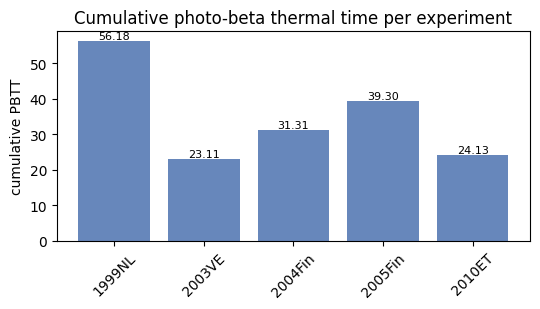

In [ ]:
cum_PBTT = {}
for study in STUDIES:
    df_weather[study], cum_PBTT[study] = calculate_PBTT(df_weather[study])

PAPER_PBTT = {"1999NL": 56.18, "2003VE": 23.11, "2004Fin": 31.31,
              "2005Fin": 39.3,  "2010ET": 24.13}   # reported in the paper (Results)
comparison = pd.DataFrame(
    {"recomputed": [round(cum_PBTT[s], 2) for s in STUDIES],
     "paper":      [PAPER_PBTT[s] for s in STUDIES]},
    index=STUDIES)
comparison["difference"] = (comparison["paper"] - comparison["recomputed"]).round(2)
print("Cumulative PBTT (photo-beta thermal time):")
display(comparison)

fig, ax = plt.subplots(figsize=(5.5, 3.2))
vals = [cum_PBTT[s] for s in STUDIES]
bars = ax.bar(STUDIES, vals, color="#4c72b0", alpha=0.85)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)
ax.set_ylabel("cumulative PBTT")
ax.set_title("Cumulative photo-beta thermal time per experiment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Daily weather per experiment (author section 7.1)

The author's weather query (sections 7.1) retrieves sunlight hours and daily mean temperature per station. The author's single query joins two independent observations (sunlight and temperature) inside a federated `SERVICE` block; on rdflib that join pattern is extremely slow, so we run the **same query pattern once per observed property** (author predicates and labels kept verbatim) and join the two small result tables on `date` in pandas — the same inner join the SPARQL engine would perform. Each study is mapped to its nearest station exactly as in the author notebook: `1999NL - WUR station`, `2003VE - Merida station`, `2004Fin/2005Fin - Ruuki station` (split at 2005-01-01), `2010ET - Holeta station`.

(Japanese) 試験ごとに対応する気象ステーションの日照時間と日平均気温を取得します。

,1999NL,2003VE,2004Fin,2005Fin,2010ET
bmID,,,,,
WUR:CE011,887.095,142.5,2584.586667,170.657143,254.916667
WUR:CE047,707.325,230.0,2833.796667,403.083333,442.083333
WUR:CE067,956.275,62.5,2022.780000,297.777778,300.416667
WUR:CE070,1371.640,125.0,2036.176667,231.288889,234.090909
WUR:CE100,632.920,127.5,1823.530000,681.477778,366.500000


saved: /content/tuber_weight_best_worst_vs_PBTT.csv


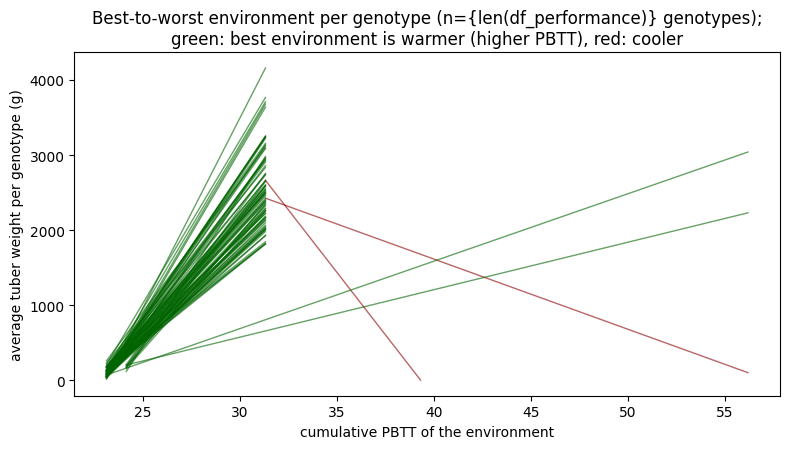

In [ ]:
base = df_averageWeightPerGenotype.set_index("bmID")[STUDIES].apply(pd.to_numeric)
df_performance = base.copy()
df_performance["max_study"] = base.idxmax(axis=1)
df_performance["max_val"]   = base.max(axis=1)
df_performance["min_val"]   = base.min(axis=1)
df_performance["min_study"] = base.idxmin(axis=1)
df_perf_ordered = df_performance[STUDIES]
display(df_perf_ordered.head())

export_cols = STUDIES + ["min_study", "min_val", "max_study", "max_val"]
df_performance[export_cols].round(2).to_csv(
    "/content/tuber_weight_best_worst_vs_PBTT.csv", index=True)
print("saved: /content/tuber_weight_best_worst_vs_PBTT.csv")

fig, ax = plt.subplots(figsize=(8, 4.6))
for gid, row in df_performance.iterrows():
    lo_s, hi_s = row["min_study"], row["max_study"]
    color = "darkgreen" if cum_PBTT[hi_s] > cum_PBTT[lo_s] else "darkred"
    ax.plot([cum_PBTT[lo_s], cum_PBTT[hi_s]],
            [row["min_val"], row["max_val"]],
            color=color, alpha=0.6, linewidth=1)
ax.set_xlabel("cumulative PBTT of the environment")
ax.set_ylabel("average tuber weight per genotype (g)")
ax.set_title(f"Best-to-worst environment per genotype (n={{len(df_performance)}} genotypes);\n"
             "green: best environment is warmer (higher PBTT), red: cooler")
plt.tight_layout()
plt.show()

## 9. Cumulative photo-beta thermal time (PBTT) per experiment

Verbatim author functions (`formula_btt`, `calculate_PBTT`): daily **beta thermal time** from the mean temperature, multiplied by the photoperiod fraction (hours of sunlight / 24), then cumulated over the season. The paper reports **1999NL 56.18; 2003VE 23.11; 2004Fin 31.31; 2005Fin 39.3; 2010ET 24.13** - compared below with our recomputed values.

(Japanese) 著者関数をそのまま用い、日平均気温と日照時間から累積PBTTを試験ごとに計算し、論文記載値と比較します。

## 10. Trait x environment: best and worst environment per genotype vs PBTT

Following the author's section 7.3: for every genotype measured in all five experiments, find the environment with the best (max) and worst (min) average tuber weight, then plot each genotype's min-max segment against the two environments' cumulative PBTT. Green = the better environment is also the warmer one (higher PBTT); red = the better environment is the cooler one.

The underlying table is exported to `/content/tuber_weight_best_worst_vs_PBTT.csv`.

(Japanese) 各遺伝型の最良・最悪環境を求め、累積PBTTを横軸に描画します。結果表はCSVにも書き出します。

## 11. Interpretation and validation record

**What was reproduced** - the paper's data-reuse milestones on the authors' FAIRified RDF: study-metadata exploration; the genotype-overlap check (paper: 101 common / 292 total genotypes); station-to-site matching; per-genotype tuber-weight aggregation across the five experiments; cumulative PBTT per experiment (paper values: 56.18 / 23.11 / 31.31 / 39.3 / 24.13); and the best-vs-worst environment plot against PBTT (cf. paper Fig. 7b and the PBTT discussion in Results).

**What was NOT reproduced** - the FAIR Data Point web service (`server-fdp`/Flask), the Fuseki server itself, and the Excel-to-RDF conversion notebook: Colab cannot host those services, so the reuse scenario starts from the authors' generated RDF files, exactly as the author exploration notebook does. Author plotly chart variants (stacked bars, plant-height analysis, all-environments scatter) were omitted as redundant visual variants of the same computation.

**Provenance** - paper: DOI 10.1038/s41597-023-02364-z (CC BY 4.0). Code and data: github.com/PBR/FAIR_CxE tag `v1.0`, commit `485c6eb642f916f695b0602f69fa23ebfcffa0ae` (GPL-3.0; the same code+data snapshot is archived on Zenodo records 7900967 and 5572772). Blob integrity of every downloaded TTL was verified in-cell. This notebook is an AI-authored Colab adaptation (rdflib replaces Fuseki; matplotlib replaces plotly); it is not author-provided and a single executed example does not verify the paper's dataset-level claims.

(Japanese) 論文のデータ再利用マイルストーン(メタデータ探索、遺伝型重複101/292の確認、気象データの対応付け、塊茎重集計、PBTT統合)を著者のRDFデータ上で再実行しました。Fusekiサーバ・FDP・Excel→RDF変換は再現対象外です。本ノートブックはAIによるColab移植であり、単一実行例は論文のデータセットレベルの主張の検証ではありません。出典・ライセンス(論文CC BY 4.0、コードGPL-3.0)は上記の通りです。